<a href="https://colab.research.google.com/github/Fordfire337/CS-4410-intro-machine-learning/blob/main/ImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import sys
import time
import urllib.request
from pathlib import Path

import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from torchvision.models import (
    resnet18, ResNet18_Weights,
    resnet50, ResNet50_Weights,
    mobilenet_v2, MobileNet_V2_Weights,
)

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
try:
    import torchvision
    print("Torchvision:", torchvision.__version__)
except Exception as e:
    print("Torchvision version check failed:", e)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type != "cuda":
    print("WARNING: GPU is not enabled. In Colab, use Runtime -> Change runtime type -> GPU")

Python: 3.12.12
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
Device: cuda


In [8]:
MODEL_NAME = "resnet18"  # change to "resnet50" or "mobilenet_v2" for other models

def load_model_and_weights(model_name: str):
    model_name = model_name.lower()

    if model_name == "resnet18":
        weights = ResNet18_Weights.DEFAULT
        model = resnet18(weights=weights)
    elif model_name == "resnet50":
        weights = ResNet50_Weights.DEFAULT
        model = resnet50(weights=weights)
    elif model_name == "mobilenet_v2":
        weights = MobileNet_V2_Weights.DEFAULT
        model = mobilenet_v2(weights=weights)
    else:
        raise ValueError("MODEL_NAME must be one of: resnet18, resnet50, mobilenet_v2")

    model = model.to(device)
    model.eval()
    preprocess = weights.transforms()
    categories = weights.meta["categories"]
    return model, preprocess, categories, weights

model, preprocess, categories, weights = load_model_and_weights(MODEL_NAME)
print("Loaded model:", MODEL_NAME)
print("Number of ImageNet classes:", len(categories))
print("First 5 classes:", categories[:5])

Loaded model: resnet18
Number of ImageNet classes: 1000
First 5 classes: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


In [9]:
from pathlib import Path
from google.colab import files

download_dir = Path("sample_images")
download_dir.mkdir(exist_ok=True)

print("Upload at least 3 images from your computer.")
uploaded = files.upload()

local_images = {}
for name in uploaded.keys():
    local_images[Path(name).stem] = Path(name)

if len(local_images) < 3:
    raise ValueError("Please upload at least 3 images.")

local_images

Upload at least 3 images from your computer.


Saving Green_Sea_Turtle_grazing_seagrass.jpg to Green_Sea_Turtle_grazing_seagrass.jpg
Saving 320px-Felis_catus-cat_on_snow.jpg to 320px-Felis_catus-cat_on_snow.jpg
Saving dog.jpg to dog (1).jpg


{'Green_Sea_Turtle_grazing_seagrass': PosixPath('Green_Sea_Turtle_grazing_seagrass.jpg'),
 '320px-Felis_catus-cat_on_snow': PosixPath('320px-Felis_catus-cat_on_snow.jpg'),
 'dog (1)': PosixPath('dog (1).jpg')}

In [10]:
def predict_top5(image_path: Path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    start = time.time()
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = F.softmax(outputs, dim=1)[0]
    elapsed = time.time() - start

    top5_prob, top5_idx = torch.topk(probabilities, 5)

    top5 = []
    for prob, idx in zip(top5_prob.cpu().tolist(), top5_idx.cpu().tolist()):
        top5.append({
            "class_name": categories[idx],
            "confidence": prob,
            "confidence_percent": prob * 100
        })

    return image, top5, elapsed

In [11]:
all_results = {}

for name, image_path in local_images.items():
    image, top5, elapsed = predict_top5(image_path)
    all_results[name] = {
        "image": image,
        "top5": top5,
        "inference_seconds": elapsed
    }

print("Finished inference for", len(all_results), "images.")

Finished inference for 3 images.


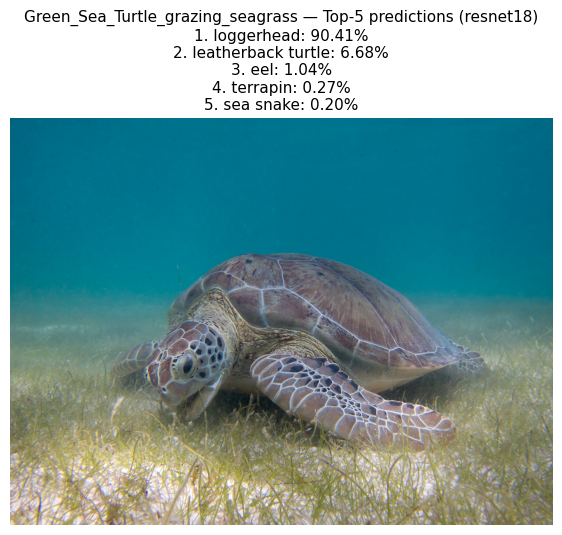

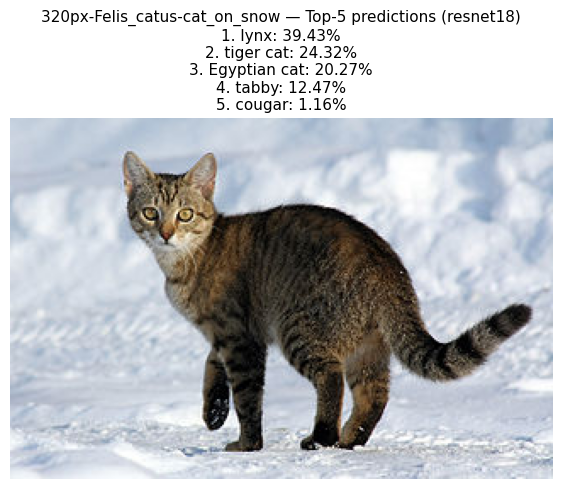

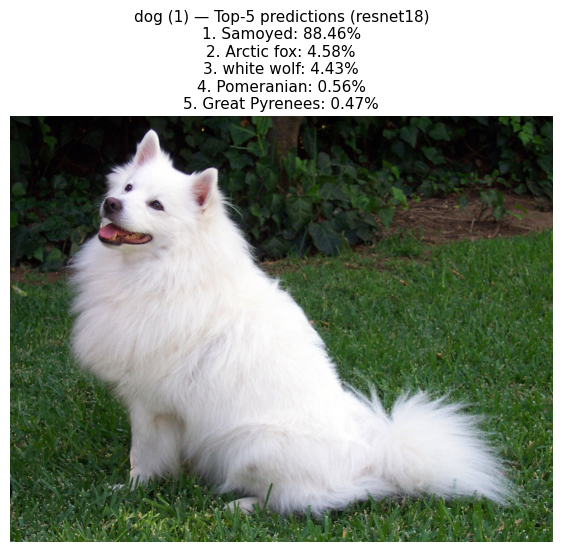

In [12]:
for name, result in all_results.items():
    image = result["image"]
    top5 = result["top5"]

    title_lines = [f"{name} — Top-5 predictions ({MODEL_NAME})"]
    for rank, item in enumerate(top5, start=1):
        title_lines.append(f"{rank}. {item['class_name']}: {item['confidence_percent']:.2f}%")

    plt.figure(figsize=(7, 7))
    plt.imshow(image)
    plt.axis("off")
    plt.title("\n".join(title_lines), fontsize=11)
    plt.show()

In [13]:
rows = []
for image_name, result in all_results.items():
    for rank, item in enumerate(result["top5"], start=1):
        rows.append({
            "image": image_name,
            "rank": rank,
            "predicted_class": item["class_name"],
            "confidence_percent": round(item["confidence_percent"], 4),
            "inference_seconds": round(result["inference_seconds"], 4),
            "model": MODEL_NAME,
        })

summary_df = pd.DataFrame(rows)
summary_df

,image,rank,predicted_class,confidence_percent,inference_seconds,model
0,Green_Sea_Turtle_grazing_seagrass,1,loggerhead,90.4068,0.9022,resnet18
1,Green_Sea_Turtle_grazing_seagrass,2,leatherback turtle,6.6792,0.9022,resnet18
2,Green_Sea_Turtle_grazing_seagrass,3,eel,1.0441,0.9022,resnet18
3,Green_Sea_Turtle_grazing_seagrass,4,terrapin,0.2664,0.9022,resnet18
4,Green_Sea_Turtle_grazing_seagrass,5,sea snake,0.2038,0.9022,resnet18
5,320px-Felis_catus-cat_on_snow,1,lynx,39.4344,0.0027,resnet18
6,320px-Felis_catus-cat_on_snow,2,tiger cat,24.3151,0.0027,resnet18
7,320px-Felis_catus-cat_on_snow,3,Egyptian cat,20.2716,0.0027,resnet18
8,320px-Felis_catus-cat_on_snow,4,tabby,12.4746,0.0027,resnet18
9,320px-Felis_catus-cat_on_snow,5,cougar,1.1634,0.0027,resnet18


In [14]:
for image_name, result in all_results.items():
    print(f"\n{image_name} ({MODEL_NAME})")
    for item in result["top5"]:
        print(f"{item['class_name']}: {item['confidence_percent']:.2f}%")


Green_Sea_Turtle_grazing_seagrass (resnet18)
loggerhead: 90.41%
leatherback turtle: 6.68%
eel: 1.04%
terrapin: 0.27%
sea snake: 0.20%

320px-Felis_catus-cat_on_snow (resnet18)
lynx: 39.43%
tiger cat: 24.32%
Egyptian cat: 20.27%
tabby: 12.47%
cougar: 1.16%

dog (1) (resnet18)
Samoyed: 88.46%
Arctic fox: 4.58%
white wolf: 4.43%
Pomeranian: 0.56%
Great Pyrenees: 0.47%
